## m9 — 5-Class with Balanced Relabeling

Same GazeNetM5 architecture and training setup as m5c, but:
- **5 classes** (Up, Down, Left, Right, Straight) — Straight is NOT filtered
- **Balanced relabeled coordinates** — shift (-0.30, -3.60)

**Rationale:** With the balanced shift, Straight is centered at the approximate
screen center rather than the camera. It now represents a coherent visual
concept ("looking at the middle of the screen") rather than the incoherent
camera-centered Straight that caused the original 5→4 class accuracy jump.

The Straight zone acts as a buffer between Up and Down, absorbing ambiguous
near-center samples that forced the 4-class model into hard commitments.
At inference time, confidence thresholding still handles "no selection."

**Balanced 5-class distribution:**
- Straight: 33.9%
- Up: 13.1%
- Down: 12.1%
- Left: 20.4%
- Right: 20.5%

## Setup

In [1]:
!pip install webdataset -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 8.4 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA A100-SXM4-80GB


In [4]:
import os, glob, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import webdataset as wds
from torchvision import transforms
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_recall_fscore_support

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Imports loaded, device: {device}")

Imports loaded, device: cuda


In [5]:
# ============================================================
# ALL PATHS
# ============================================================

TAR_DIR         = "/content/gaze_wds_balanced"
LABELS_CSV      = "/content/drive/MyDrive/210/gaze_labels_balanced.csv"
GEO_PARQUET     = "/content/drive/MyDrive/210/geo_features_v1.parquet"

MODEL_NAME      = "m9"
CHECKPOINT_PATH = f"/content/drive/MyDrive/210/{MODEL_NAME}.pth"

print(f"LABELS_CSV:  {LABELS_CSV} — {os.path.exists(LABELS_CSV)}")
print(f"GEO_PARQUET: {GEO_PARQUET} — {os.path.exists(GEO_PARQUET)}")
print(f"CHECKPOINT:  {CHECKPOINT_PATH}")

LABELS_CSV:  /content/drive/MyDrive/210/gaze_labels_balanced.csv — True
GEO_PARQUET: /content/drive/MyDrive/210/geo_features_v1.parquet — True
CHECKPOINT:  /content/drive/MyDrive/210/m9.pth


## Load data to disk

In [6]:
# ============================================================
# COPY TARS TO LOCAL COLAB DISK
# ============================================================

for split in ['train', 'val', 'test']:
    local_dir = f'{TAR_DIR}/{split}'
    os.makedirs(local_dir, exist_ok=True)
    source = f'/content/drive/MyDrive/210/gaze_wds_balanced/{split}/'
    tar_files = sorted(glob.glob(source + '*.tar'))
    for f in tar_files:
        fname = os.path.basename(f)
        dest = f"{local_dir}/{fname}"
        if not os.path.exists(dest):
            os.system(f"cp '{f}' '{dest}'")
    count = len([f for f in os.listdir(local_dir) if f.endswith('.tar')])
    print(f"{split}: {count} tars copied")

train: 75 tars copied
val: 16 tars copied
test: 16 tars copied


In [7]:
# ============================================================
# VERIFY TAR FILES
# ============================================================

train_tar_urls = sorted(glob.glob(f"{TAR_DIR}/train/*.tar"))
val_tar_urls   = sorted(glob.glob(f"{TAR_DIR}/val/*.tar"))
test_tar_urls  = sorted(glob.glob(f"{TAR_DIR}/test/*.tar"))

print(f"Train tars: {len(train_tar_urls)}")
print(f"Val tars:   {len(val_tar_urls)}")
print(f"Test tars:  {len(test_tar_urls)}")

Train tars: 75
Val tars:   16
Test tars:  16


In [8]:
# ============================================================
# LOAD LABELS — 5-class, NO Straight filtering
# ============================================================

label_map_5 = {'Up': 0, 'Down': 1, 'Left': 2, 'Right': 3, 'Straight': 4}
label_names = ['Up', 'Down', 'Left', 'Right', 'Straight']

df_labels = pd.read_csv(LABELS_CSV, dtype={'subject_id': str})
print(f"Loaded {len(df_labels)} labeled frames")

label_lookup = {}
for _, row in df_labels.iterrows():
    key = f"{int(row['subject_id']):05d}_{int(row['frame_idx']):06d}"
    label_lookup[key] = row['label']

print(f"Label lookup: {len(label_lookup)} entries")
print(f"\n5-class distribution:")
counts = pd.Series(label_lookup.values()).value_counts().sort_index()
for lbl, ct in counts.items():
    print(f"  {lbl:10s}: {ct:>7,} ({ct/len(label_lookup)*100:.1f}%)")

Loaded 849131 labeled frames
Label lookup: 849131 entries

5-class distribution:
  Down      : 102,624 (12.1%)
  Left      : 172,884 (20.4%)
  Right     : 174,189 (20.5%)
  Straight  : 287,993 (33.9%)
  Up        : 111,441 (13.1%)


In [9]:
# ============================================================
# LOAD GEO FEATURES
# ============================================================

df_geo = pd.read_parquet(GEO_PARQUET)
print(f"Loaded geo features: {len(df_geo)} rows")

geo_cols = ['left_iris_h', 'right_iris_h', 'iris_h_agreement',
            'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

geo_lookup = {}
for _, row in df_geo.iterrows():
    geo_lookup[row['key']] = row[geo_cols].values.astype(np.float32)

GEO_DEFAULT = np.array([0.5, 0.5, 0.0, 0.0, 0.35, -0.1, -0.26], dtype=np.float32)

matched = sum(1 for k in label_lookup if k in geo_lookup)
print(f"Geo coverage: {matched}/{len(label_lookup)} ({100*matched/len(label_lookup):.1f}%)")

Loaded geo features: 273462 rows
Geo coverage: 273462/849131 (32.2%)


You're fine — this is the same denominator mismatch you caught before. The geo parquet has 273K entries, and the label CSV has 849K entries, but the balanced tars only contain ~320K samples (500 frames per subject). During training, WebDataset iterates over the tars, not the CSV. The 273K geo features cover ~97% of the samples that actually appear in the tars — same coverage m5c had.
The 32.2% is just 273K / 849K, which is a misleading comparison. The samples with missing geo are ones that exist in the CSV but aren't in the tars, so they'll never be seen during training anyway. The GEO_DEFAULT fallback handles the ~3% that are in the tars but missing from the parquet.
No need to rerun anything.

## Transforms & Data Pipeline

In [10]:
# ============================================================
# IMAGE TRANSFORMS (identical to m5c)
# ============================================================

eye_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

eye_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Transforms defined")

Transforms defined


In [11]:
# ============================================================
# make_dataset_5class — ALL samples, including Straight
# ============================================================

def make_dataset_5class(tar_urls, eye_transform, face_transform, shuffle=True):

    def filter_and_transform(sample):
        key = sample["__key__"]

        label_str = label_lookup.get(key)
        if label_str is None:
            return None

        face = np.array(sample["face.jpg"])
        left_eye = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        if eye_transform:
            left_eye = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        label_idx = label_map_5[label_str]

        return {
            'left_eye': left_eye,
            'right_eye': right_eye,
            'face': face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'label': torch.tensor(label_idx, dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print("make_dataset_5class defined")

make_dataset_5class defined


## Model Definition

In [12]:
# ============================================================
# GazeNetM5 — same architecture, num_classes=5
# ============================================================

class GazeNetM5(nn.Module):
    def __init__(self, num_classes=5, geo_feat_dim=7):
        super(GazeNetM5, self).__init__()

        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 64), nn.ReLU(),
        )

        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, left_eye, right_eye, face, geo_features):
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)
        face_feat  = self.face_cnn(face).view(face.size(0), -1)
        geo_feat   = self.geo_mlp(geo_features)
        combined = torch.cat([left_feat, right_feat, face_feat, geo_feat], dim=1)
        return self.fc(combined)

print("GazeNetM5 defined (5-class)")
_test = GazeNetM5(num_classes=5)
print(f"  Parameters: {sum(p.numel() for p in _test.parameters()):,}")
print(f"  FC output: {_test.fc[-1].weight.shape}")
del _test

GazeNetM5 defined (5-class)
  Parameters: 6,587,077
  FC output: torch.Size([5, 256])


## Model Setup

In [13]:
# ============================================================
# DATA LOADERS
# ============================================================

train_dataset = make_dataset_5class(train_tar_urls, eye_transform_aug,   face_transform_aug,   shuffle=True)
val_dataset   = make_dataset_5class(val_tar_urls,   eye_transform_clean, face_transform_clean, shuffle=False)
test_dataset  = make_dataset_5class(test_tar_urls,  eye_transform_clean, face_transform_clean, shuffle=False)

train_loader = wds.WebLoader(train_dataset, batch_size=32, num_workers=2, pin_memory=True)
val_loader   = wds.WebLoader(val_dataset,   batch_size=32, num_workers=2, pin_memory=True)
test_loader  = wds.WebLoader(test_dataset,  batch_size=32, num_workers=2, pin_memory=True)

print("Loaders ready")

Loaders ready


In [14]:
# ============================================================
# CLASS WEIGHTS (sqrt inverse frequency, dynamic)
# ============================================================

all_labels_list = list(label_lookup.values())
train_counts = [all_labels_list.count(c) for c in label_names]
total = sum(train_counts)
n_classes = 5
weights = [math.sqrt(total / (n_classes * c)) for c in train_counts]
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

print(f"5-class weights (sqrt inv freq):")
for name, ct, w in zip(label_names, train_counts, weights):
    print(f"  {name:10s}: {ct:>7,} ({ct/total*100:.1f}%)  weight={w:.3f}")

5-class weights (sqrt inv freq):
  Up        : 111,441 (13.1%)  weight=1.234
  Down      : 102,624 (12.1%)  weight=1.286
  Left      : 172,884 (20.4%)  weight=0.991
  Right     : 174,189 (20.5%)  weight=0.987
  Straight  : 287,993 (33.9%)  weight=0.768


In [15]:
# ============================================================
# MODEL, LOSS, OPTIMIZER
# ============================================================

model = GazeNetM5(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3)

print(f"Model: GazeNetM5 (5-class)")
print(f"Loss:  CrossEntropy (weighted, label_smoothing=0.1)")
print(f"Optimizer: Adam (lr=1e-4, wd=5e-4)")

Model: GazeNetM5 (5-class)
Loss:  CrossEntropy (weighted, label_smoothing=0.1)
Optimizer: Adam (lr=1e-4, wd=5e-4)


## Check Class Balance

train: 197374 samples, distribution: {0: 25332, 1: 24736, 2: 39011, 3: 39543, 4: 68752}
val: 40175 samples, distribution: {0: 4673, 1: 4899, 2: 7878, 3: 7506, 4: 15219}
test: 42733 samples, distribution: {0: 5480, 1: 5028, 2: 8457, 3: 8373, 4: 15395}


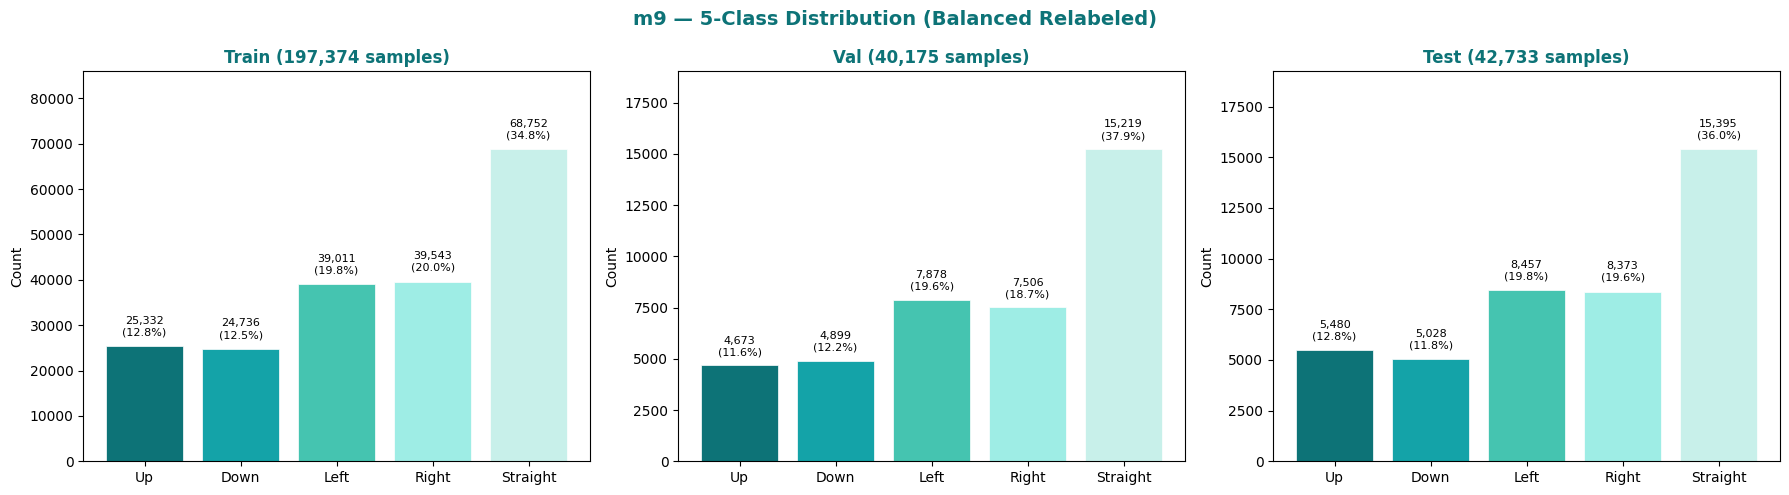

In [16]:
# ============================================================
# CHECK CLASS BALANCE (per split)
# ============================================================

label_names_map = {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right', 4: 'Straight'}
teal_colors = ['#0D7377', '#14A3A8', '#45C4B0', '#9EEDE5', '#C8F0EA']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, loader) in zip(axes, [("train", train_loader), ("val", val_loader), ("test", test_loader)]):
    counts = {i: 0 for i in range(5)}
    total = 0
    for batch in loader:
        for lbl in batch['label'].tolist():
            counts[lbl] += 1
            total += 1

    class_names = [label_names_map[i] for i in range(5)]
    class_counts = [counts[i] for i in range(5)]
    bars = ax.bar(class_names, class_counts, color=teal_colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{name.capitalize()} ({total:,} samples)', fontsize=12, fontweight='bold', color='#0D7377')
    ax.set_ylabel('Count')
    for bar, c in zip(bars, class_counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                f'{c:,}\n({100*c/total:.1f}%)', ha='center', va='bottom', fontsize=8)
    ax.set_ylim(0, max(class_counts) * 1.25)

    print(f"{name}: {total} samples, distribution: {counts}")

plt.suptitle('m9 — 5-Class Distribution (Balanced Relabeled)', fontsize=14, fontweight='bold', color='#0D7377')
plt.tight_layout()
plt.show()

## Smoke Test

In [17]:
# ============================================================
# SMOKE TEST
# ============================================================

test_tar = [train_tar_urls[0]]
test_ds = make_dataset_5class(test_tar, eye_transform_clean, face_transform_clean, shuffle=False)
smoke_loader = wds.WebLoader(test_ds, batch_size=4, num_workers=0)

batch = next(iter(smoke_loader))

print(f"left_eye:     {batch['left_eye'].shape}")
print(f"right_eye:    {batch['right_eye'].shape}")
print(f"face:         {batch['face'].shape}")
print(f"geo_features: {batch['geo_features'].shape}")
print(f"label:        {batch['label'].shape}")
print(f"label values: {batch['label'].tolist()}  (should be 0-4)")

model.eval()
with torch.no_grad():
    out = model(
        batch['left_eye'].to(device),
        batch['right_eye'].to(device),
        batch['face'].to(device),
        batch['geo_features'].to(device),
    )
print(f"Output: {out.shape}  <-- should be [4, 5]")
print("Pipeline works!")

left_eye:     torch.Size([4, 3, 48, 48])
right_eye:    torch.Size([4, 3, 48, 48])
face:         torch.Size([4, 3, 112, 112])
geo_features: torch.Size([4, 7])
label:        torch.Size([4])
label values: [4, 4, 4, 4]  (should be 0-4)
Output: torch.Size([4, 5])  <-- should be [4, 5]
Pipeline works!


## Train

In [18]:
# ============================================================
# TRAINING LOOP — identical to m5c, just 5 classes
# ============================================================

num_epochs = 20
best_val_loss = float('inf')

patience = 6
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*50}")

    # ---- Train ----
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    epoch_start = time.time()

    for batch_idx, batch in enumerate(train_loader):
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face, geo_features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 1000 == 0:
            elapsed = time.time() - epoch_start
            batches_done = batch_idx + 1
            eta_minutes = (elapsed / batches_done) * (7000 - batches_done) / 60
            print(f"  Batch {batches_done}/~7000 - Loss: {loss.item():.4f} - ETA: {eta_minutes:.1f} min")

    if train_total == 0:
        raise RuntimeError("Train loader yielded 0 samples — check label key format")

    avg_train_loss = train_loss / (batch_idx + 1)
    train_acc = 100 * train_correct / train_total
    epoch_time = time.time() - epoch_start

    # ---- Validate ----
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    val_batch_count = 0

    with torch.no_grad():
        for batch in val_loader:
            val_batch_count += 1
            left_eye     = batch['left_eye'].to(device)
            right_eye    = batch['right_eye'].to(device)
            face         = batch['face'].to(device)
            geo_features = batch['geo_features'].to(device)
            labels       = batch['label'].to(device)

            outputs = model(left_eye, right_eye, face, geo_features)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / val_batch_count
    val_acc = 100 * val_correct / val_total

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(avg_val_loss)

    print(f"\n  Time: {epoch_time/60:.1f} min")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Gap: {train_acc - val_acc:.2f}%")

    # ---- Checkpoint ----
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  Saved best model (val_loss={avg_val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")

    # ---- Early stopping ----
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.4f}")


Epoch 1/20
  Batch 1000/~7000 - Loss: 1.0817 - ETA: 12.3 min
  Batch 2000/~7000 - Loss: 0.9289 - ETA: 10.3 min
  Batch 3000/~7000 - Loss: 1.1944 - ETA: 8.3 min
  Batch 4000/~7000 - Loss: 0.9917 - ETA: 6.1 min
  Batch 5000/~7000 - Loss: 1.0049 - ETA: 4.0 min
  Batch 6000/~7000 - Loss: 1.0001 - ETA: 2.0 min

  Time: 12.5 min
  Train Loss: 1.1029 | Train Acc: 63.48%
  Val Loss:   0.9918 | Val Acc:   69.85%
  Gap: -6.37%
  Saved best model (val_loss=0.9918)

Epoch 2/20
  Batch 1000/~7000 - Loss: 1.0666 - ETA: 12.4 min
  Batch 2000/~7000 - Loss: 0.7980 - ETA: 10.4 min
  Batch 3000/~7000 - Loss: 0.9067 - ETA: 8.3 min
  Batch 4000/~7000 - Loss: 0.9515 - ETA: 6.1 min
  Batch 5000/~7000 - Loss: 0.8762 - ETA: 4.0 min
  Batch 6000/~7000 - Loss: 0.8116 - ETA: 2.0 min

  Time: 12.5 min
  Train Loss: 0.9429 | Train Acc: 72.59%
  Val Loss:   0.9704 | Val Acc:   69.21%
  Gap: 3.38%
  Saved best model (val_loss=0.9704)

Epoch 3/20
  Batch 1000/~7000 - Loss: 0.9457 - ETA: 12.3 min
  Batch 2000/~7000 - 

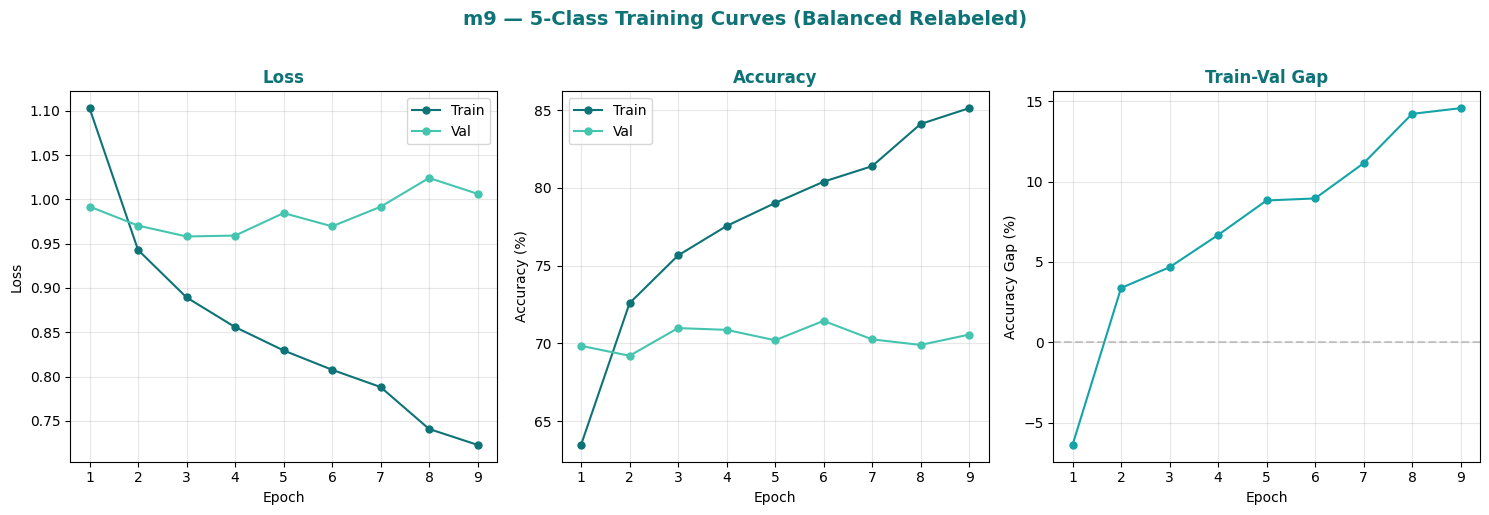


Total epochs: 9
Best val loss: 0.9581 (epoch 3)
Best val acc:  71.45% (epoch 6)


In [19]:
# ============================================================
# TRAINING CURVES
# ============================================================

teal_dark  = '#0D7377'
teal_mid   = '#14A3A8'
teal_light = '#45C4B0'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
ep = range(1, len(train_losses) + 1)

axes[0].plot(ep, train_losses, '-o', color=teal_dark, label='Train', markersize=5)
axes[0].plot(ep, val_losses, '-o', color=teal_light, label='Val', markersize=5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss', fontweight='bold', color=teal_dark)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(ep, train_accuracies, '-o', color=teal_dark, label='Train', markersize=5)
axes[1].plot(ep, val_accuracies, '-o', color=teal_light, label='Val', markersize=5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy', fontweight='bold', color=teal_dark)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

gap = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
axes[2].plot(ep, gap, '-o', color=teal_mid, markersize=5)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.4)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy Gap (%)')
axes[2].set_title('Train-Val Gap', fontweight='bold', color=teal_dark)
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{MODEL_NAME} — 5-Class Training Curves (Balanced Relabeled)',
             fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nTotal epochs: {len(train_losses)}")
print(f"Best val loss: {min(val_losses):.4f} (epoch {val_losses.index(min(val_losses)) + 1})")
print(f"Best val acc:  {max(val_accuracies):.2f}% (epoch {val_accuracies.index(max(val_accuracies)) + 1})")

## Test Evaluation

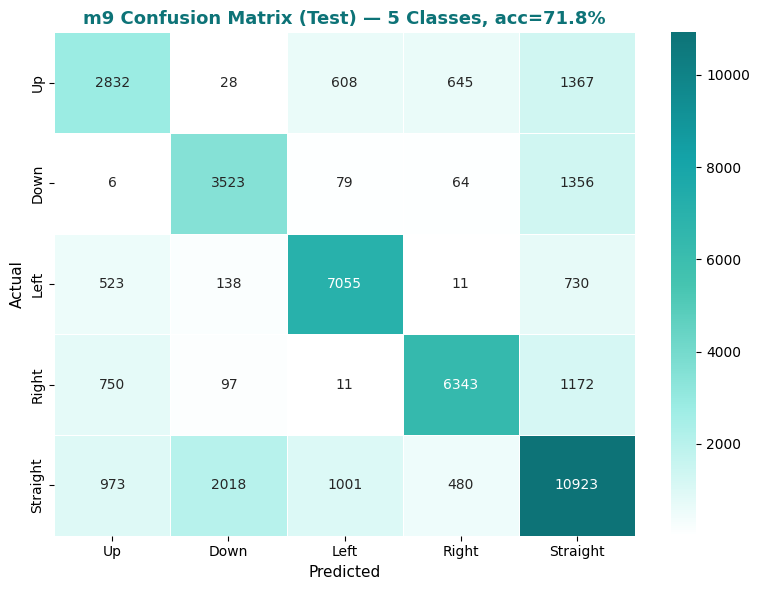


m9 Test Set Performance (5-class)
              precision    recall  f1-score   support

          Up       0.56      0.52      0.54      5480
        Down       0.61      0.70      0.65      5028
        Left       0.81      0.83      0.82      8457
       Right       0.84      0.76      0.80      8373
    Straight       0.70      0.71      0.71     15395

    accuracy                           0.72     42733
   macro avg       0.70      0.70      0.70     42733
weighted avg       0.72      0.72      0.72     42733



In [20]:
# ============================================================
# TEST EVALUATION — 5 classes
# ============================================================

model.load_state_dict(torch.load(CHECKPOINT_PATH))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        outputs = model(left_eye, right_eye, face, geo_features)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ---- Confusion matrix ----
teal_cmap = LinearSegmentedColormap.from_list(
    'teal', ['#FFFFFF', '#9EEDE5', '#45C4B0', '#14A3A8', '#0D7377'])

cm = confusion_matrix(all_labels, all_preds)
test_acc = 100 * np.sum(np.diag(cm)) / np.sum(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap=teal_cmap,
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='white')
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.title(f'{MODEL_NAME} Confusion Matrix (Test) — 5 Classes, acc={test_acc:.1f}%',
          fontweight='bold', color='#0D7377', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n{'='*50}")
print(f"{MODEL_NAME} Test Set Performance (5-class)")
print(f"{'='*50}")
print(classification_report(all_labels, all_preds, target_names=label_names))

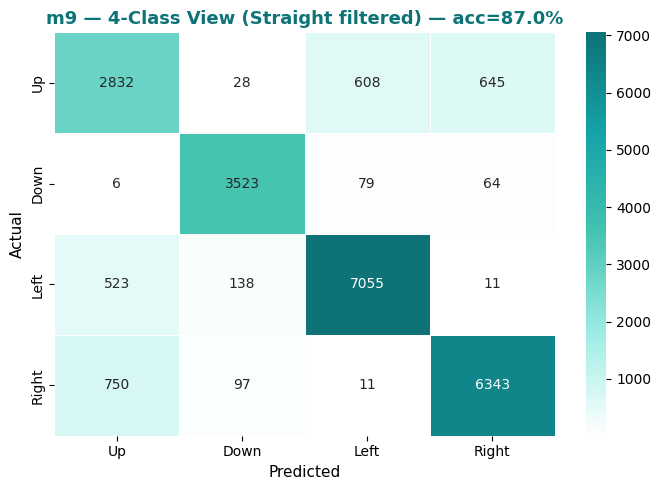


4-class view (both pred and label are directional):
  Samples: 22,713 / 42,733
  Accuracy: 87.0%
              precision    recall  f1-score   support

          Up       0.69      0.69      0.69      4113
        Down       0.93      0.96      0.94      3672
        Left       0.91      0.91      0.91      7727
       Right       0.90      0.88      0.89      7201

    accuracy                           0.87     22713
   macro avg       0.86      0.86      0.86     22713
weighted avg       0.87      0.87      0.87     22713


Straight predictions: 15,548 / 42,733 (36.4%)
Straight true labels: 15,395 / 42,733 (36.0%)


In [21]:
# ============================================================
# 4-CLASS VIEW — filter Straight from predictions+labels
# for comparison with m5c and m8 results
# ============================================================

all_preds_np = np.array(all_preds)
all_labels_np = np.array(all_labels)

# Mask: keep only samples where BOTH true label and prediction are non-Straight
# This shows how the model performs on directional classes
straight_idx = label_map_5['Straight']  # 4
mask_4c = (all_labels_np != straight_idx) & (all_preds_np != straight_idx)

preds_4c = all_preds_np[mask_4c]
labels_4c = all_labels_np[mask_4c]

label_names_4 = ['Up', 'Down', 'Left', 'Right']
cm_4c = confusion_matrix(labels_4c, preds_4c, labels=[0, 1, 2, 3])
acc_4c = 100 * np.sum(np.diag(cm_4c)) / np.sum(cm_4c) if np.sum(cm_4c) > 0 else 0

plt.figure(figsize=(7, 5))
sns.heatmap(cm_4c, annot=True, fmt='d', cmap=teal_cmap,
            xticklabels=label_names_4, yticklabels=label_names_4,
            linewidths=0.5, linecolor='white')
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.title(f'{MODEL_NAME} — 4-Class View (Straight filtered) — acc={acc_4c:.1f}%',
          fontweight='bold', color='#0D7377', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\n4-class view (both pred and label are directional):")
print(f"  Samples: {mask_4c.sum():,} / {len(all_labels):,}")
print(f"  Accuracy: {acc_4c:.1f}%")
if np.sum(cm_4c) > 0:
    print(classification_report(labels_4c, preds_4c,
                                labels=[0,1,2,3], target_names=label_names_4))

# Also show: how often does the model predict Straight?
n_pred_straight = (all_preds_np == straight_idx).sum()
n_true_straight = (all_labels_np == straight_idx).sum()
print(f"\nStraight predictions: {n_pred_straight:,} / {len(all_preds):,} ({100*n_pred_straight/len(all_preds):.1f}%)")
print(f"Straight true labels: {n_true_straight:,} / {len(all_labels):,} ({100*n_true_straight/len(all_labels):.1f}%)")

In [22]:
# ============================================================
# SAVE TRAINING CURVES & CONFIRM CHECKPOINT
# ============================================================

print(f"train_losses_{MODEL_NAME} =", train_losses)
print(f"val_losses_{MODEL_NAME} =", val_losses)
print(f"train_acc_{MODEL_NAME} =", train_accuracies)
print(f"val_acc_{MODEL_NAME} =", val_accuracies)

print(f"\nCheckpoint exists: {os.path.exists(CHECKPOINT_PATH)}")
print(f"Size: {os.path.getsize(CHECKPOINT_PATH) / 1e6:.1f} MB")

train_losses_m9 = [1.1028878323240967, 0.9428652168750453, 0.8892847653744131, 0.8558304133775478, 0.8294550904040207, 0.8076243371873051, 0.7881330499756506, 0.7408134287027534, 0.7228513303878397]
val_losses_m9 = [0.991806941745579, 0.9703553774428918, 0.9580892395337802, 0.9590781567916096, 0.9844938299204493, 0.9695168046981641, 0.9915982768378185, 1.0241209255055768, 1.0062078081290686]
train_acc_m9 = [63.475939080122004, 72.59010811961049, 75.66092798443565, 77.55276784176235, 79.03117938532938, 80.40370058873002, 81.40079240426805, 84.11391571331583, 85.13228692735619]
val_acc_m9 = [69.84691972619788, 69.20721841941506, 70.9869321717486, 70.87492221530803, 70.20535158680772, 71.45239576851276, 70.26260112009956, 69.90416925948973, 70.5687616677038]

Checkpoint exists: True
Size: 26.4 MB
